In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())

2.10.0+cpu
CUDA available: False


In [3]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
!pip install kaggle

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hungle3401/faceforensics")

print("Path to dataset files:", path)

100%|██████████| 2.73G/2.73G [00:35<00:00, 82.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hungle3401/faceforensics/versions/1


In [6]:
import os

path = "/root/.cache/kagglehub/datasets/hungle3401/faceforensics/versions/1"

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # نشوف أول مستويين بس
        subindent = ' ' * 2 * (level + 1)
        for file in files[:3]:  # أول 3 ملفات بس
            print(f'{subindent}{file}')

1/
  FF++/
    real/
    fake/


In [7]:
real_path = path + "/FF++/real"
fake_path = path + "/FF++/fake"

real_images = os.listdir(real_path)
fake_images = os.listdir(fake_path)

print(f"Real images: {len(real_images)}")
print(f"Fake images: {len(fake_images)}")
print(f"Sample real: {real_images[:3]}")
print(f"Sample fake: {fake_images[:3]}")

Real images: 200
Fake images: 200
Sample real: ['07__outside_talking_pan_laughing.mp4', '09__talking_against_wall.mp4', '15__walking_and_outside_surprised.mp4']
Sample fake: ['02_27__walk_down_hall_angry__78M8S6M6.mp4', '03_26__kitchen_pan__WBSXBL82.mp4', '07_20__outside_talking_pan_laughing__KV6Q7D6C.mp4']


Frame size: (1920, 1080)


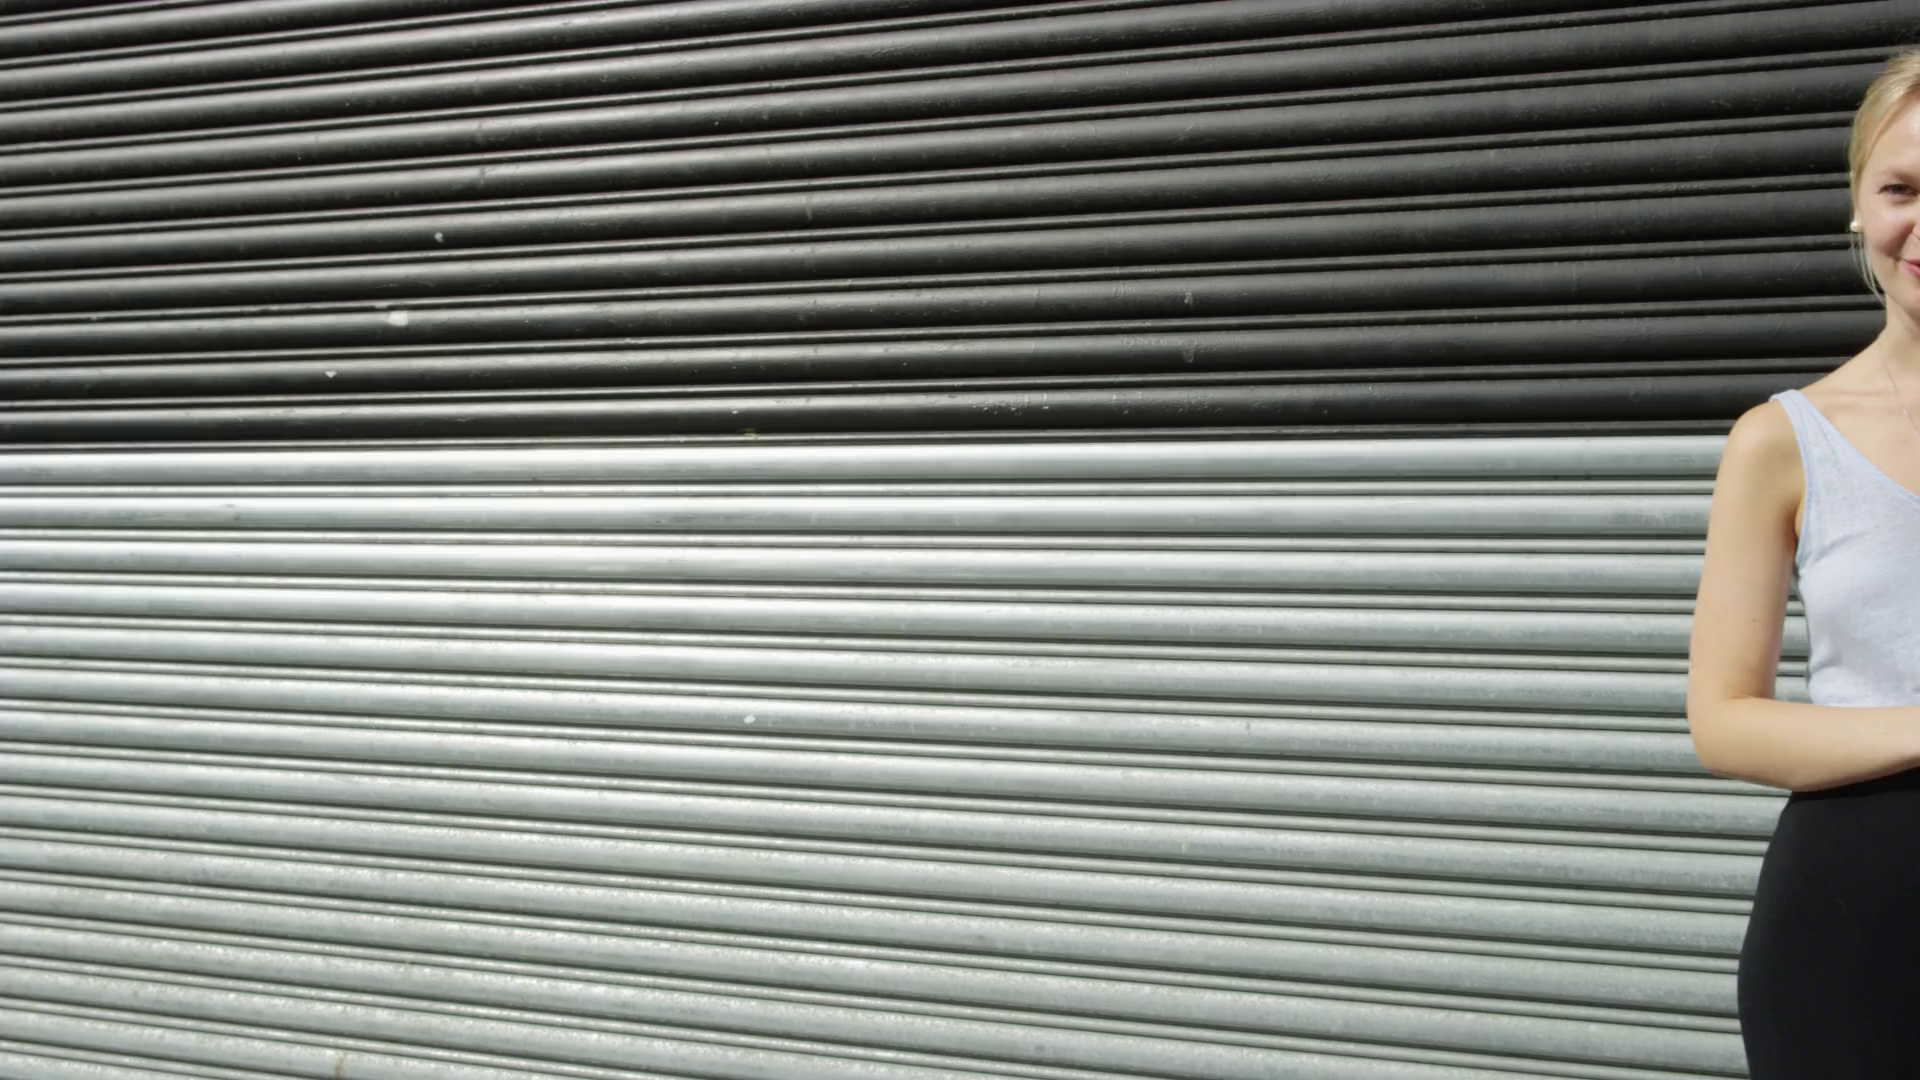

In [8]:
import cv2
from IPython.display import display
from PIL import Image

# جرب أول فيديو real
video_path = real_path + "/" + real_images[0]
cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()
if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(frame_rgb)
    print(f"Frame size: {img.size}")
    display(img)
else:
    print("Error reading video")

cap.release()

In [9]:
import cv2
import os

output_real = "/content/dataset/real"
output_fake = "/content/dataset/fake"
os.makedirs(output_real, exist_ok=True)
os.makedirs(output_fake, exist_ok=True)

def extract_frames(video_folder, output_folder, frames_per_video=5):
    videos = os.listdir(video_folder)
    total = 0
    for video in videos:
        cap = cv2.VideoCapture(video_folder + "/" + video)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        interval = total_frames // frames_per_video

        for i in range(frames_per_video):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i * interval)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, (224, 224))
                name = f"{video[:-4]}_frame{i}.jpg"
                cv2.imwrite(output_folder + "/" + name, frame)
                total += 1
        cap.release()
    print(f"Extracted {total} frames to {output_folder}")

extract_frames(real_path, output_real, frames_per_video=5)
extract_frames(fake_path, output_fake, frames_per_video=5)

Extracted 1000 frames to /content/dataset/real
Extracted 1000 frames to /content/dataset/fake


In [10]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# تحميل البيانات
dataset = datasets.ImageFolder("/content/dataset", transform=transform)
print(f"Total images: {len(dataset)}")
print(f"Classes: {dataset.classes}")

# تقسيم 80% train, 20% test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_data, test_data = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Train: {train_size} images")
print(f"Test: {test_size} images")

Total images: 2000
Classes: ['fake', 'real']
Train: 1600 images
Test: 400 images


In [12]:
import torch
import torch.nn as nn
from torchvision import models

# تحميل MobileNetV2 pretrained
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# تعديل آخر layer عشان يطلع 2 classes (real/fake)
model.classifier[1] = nn.Linear(model.last_channel, 2)

# تحديد device
device = torch.device("cpu")
model = model.to(device)

print("Model ready!")
print(f"Output classes: 2 (fake, real)")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 108MB/s] 

Model ready!
Output classes: 2 (fake, real)


In [13]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Acc: {acc:.2f}%")

print("Training done!")

Epoch 1/5 | Loss: 0.6302 | Acc: 63.44%
Epoch 2/5 | Loss: 0.5163 | Acc: 73.44%
Epoch 3/5 | Loss: 0.4955 | Acc: 76.19%
Epoch 4/5 | Loss: 0.4619 | Acc: 77.56%
Epoch 5/5 | Loss: 0.4191 | Acc: 79.75%
Training done!


In [14]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 71.00%


In [15]:
import os
os.makedirs("/content/models", exist_ok=True)

torch.save(model.state_dict(), "/content/models/mobilenetv2_deepfake.pth")
print("Model saved!")

Model saved!


In [16]:
import torch
import numpy as np
from torchvision import transforms
from PIL import Image, ImageFilter
import io

def evaluate_robustness(model, test_loader, device, noise_level=0, jpeg_quality=100):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            # تحويل التنسور لصور عشان نعدل عليها
            for i in range(len(images)):
                img = images[i].numpy().transpose(1, 2, 0)
                img = (img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406])
                img = np.clip(img * 255, 0, 255).astype(np.uint8)
                pil_img = Image.fromarray(img)

                # إضافة JPEG Compression
                if jpeg_quality < 100:
                    buffer = io.BytesIO()
                    pil_img.save(buffer, format="JPEG", quality=jpeg_quality)
                    buffer.seek(0)
                    pil_img = Image.open(buffer)

                # إضافة Noise
                if noise_level > 0:
                    img_arr = np.array(pil_img).astype(np.float32)
                    noise = np.random.normal(0, noise_level, img_arr.shape)
                    img_arr = np.clip(img_arr + noise, 0, 255).astype(np.uint8)
                    pil_img = Image.fromarray(img_arr)

                # تحويل للتنسور
                transform = transforms.Compose([
                    transforms.ToTensor(),
                    transforms.Normalize([0.485, 0.456, 0.406],
                                         [0.229, 0.224, 0.225])
                ])
                images[i] = transform(pil_img)

            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total

# تشغيل التجارب
print("Robustness Test Results:")
print(f"No degradation:        {evaluate_robustness(model, test_loader, device):.2f}%")
print(f"JPEG Quality 50:       {evaluate_robustness(model, test_loader, device, jpeg_quality=50):.2f}%")
print(f"JPEG Quality 20:       {evaluate_robustness(model, test_loader, device, jpeg_quality=20):.2f}%")
print(f"Noise level 10:        {evaluate_robustness(model, test_loader, device, noise_level=10):.2f}%")
print(f"Noise level 25:        {evaluate_robustness(model, test_loader, device, noise_level=25):.2f}%")

Robustness Test Results:
No degradation:        71.25%
JPEG Quality 50:       70.50%
JPEG Quality 20:       65.75%
Noise level 10:        56.00%
Noise level 25:        58.25%


In [17]:
# حفظ الـ notebook
from google.colab import runtime

# تحميل الـ notebook على جهازك
from google.colab import files

# حفظ النموذج
files.download("/content/models/mobilenetv2_deepfake.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>